# Finance stretch analysis: does the basin-width finding transfer?

Generates all plots/tables from `results/finance/sweep_results.csv`, plus a
directional-accuracy/calibration check and the Nero-LayerNorm-affine
ablation comparison.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.finance import FinanceReturns
from src.model import DecoderOnlyTransformer, ModelConfig
from src.train import TrainConfig, train_one_run
from src.eval_finance import evaluate_directional_metrics

df = pd.read_csv("results/finance/sweep_results.csv")
summary = (
    df.groupby(["optimizer_name", "lr"])
    .agg(mean_best_val=("best_val_loss", "mean"), n_diverged=("diverged", "sum"), n=("diverged", "count"))
    .reset_index()
)
uniform_baseline = np.log(8)  # n_bins=8 -> a model that learned nothing gets exactly this
print(f"uniform-distribution baseline (ln 8): {uniform_baseline:.4f}")
summary


uniform-distribution baseline (ln 8): 2.0794


,optimizer_name,lr,mean_best_val,n_diverged,n
0,adamw,0.000095,2.050210,0,3
1,adamw,0.000228,2.051789,0,3
2,adamw,0.000534,2.052023,0,3
3,adamw,0.001265,2.056891,0,3
4,adamw,0.003000,2.058082,0,3
5,adamw,0.007114,2.054799,0,3
6,adamw,0.016870,2.053518,0,3
7,adamw,0.040000,2.061618,0,3
8,adamw,0.094870,2.067472,0,3
9,muon,0.000633,2.052559,0,3


## Loss vs. LR

Note the y-axis scale compared to the core (text) experiment's version of
this plot: everything clusters within ~0.03 nats of the uniform baseline.
That is the headline finding here, not any particular optimizer's ranking.

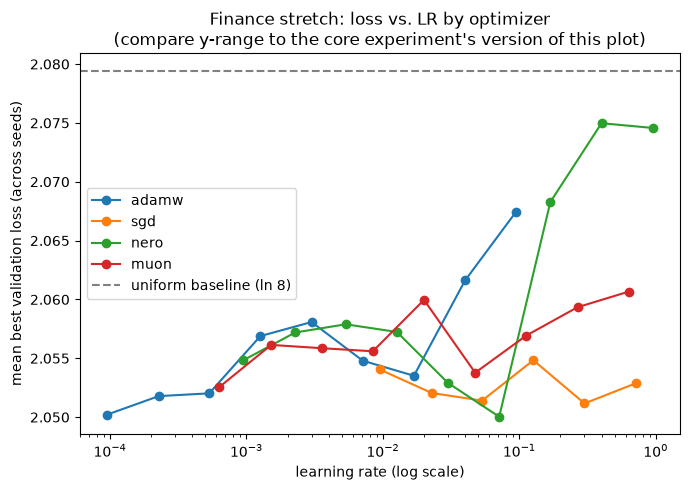

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {"adamw": "tab:blue", "sgd": "tab:orange", "nero": "tab:green", "muon": "tab:red"}
for opt in ["adamw", "sgd", "nero", "muon"]:
    sub = summary[summary.optimizer_name == opt].sort_values("lr")
    finite = sub[np.isfinite(sub.mean_best_val)]
    ax.plot(finite.lr, finite.mean_best_val, marker="o", label=opt, color=colors[opt])
ax.axhline(uniform_baseline, color="gray", linestyle="--", label="uniform baseline (ln 8)")
ax.set_xscale("log")
ax.set_xlabel("learning rate (log scale)")
ax.set_ylabel("mean best validation loss (across seeds)")
ax.set_title("Finance stretch: loss vs. LR by optimizer\n(compare y-range to the core experiment's version of this plot)")
ax.legend()
fig.tight_layout()
fig.savefig("results/finance/loss_vs_lr.png", dpi=150)
plt.show()


## Gap below the uniform baseline (how much signal is actually there)

In [3]:
rows = []
for opt in ["adamw", "sgd", "nero", "muon"]:
    sub = summary[summary.optimizer_name == opt]
    best_row = sub.loc[sub.mean_best_val.idxmin()]
    gap = uniform_baseline - best_row.mean_best_val
    rows.append({"optimizer": opt, "best_lr": best_row.lr, "best_loss": best_row.mean_best_val,
                 "gap_below_uniform": gap, "gap_pct": gap / uniform_baseline * 100})
gap_df = pd.DataFrame(rows)
gap_df


,optimizer,best_lr,best_loss,gap_below_uniform,gap_pct
0,adamw,0.000095,2.050210,0.029231,1.405716
1,sgd,0.300000,2.051167,0.028275,1.359721
2,nero,0.071140,2.050036,0.029406,1.414119
3,muon,0.000633,2.052559,0.026883,1.292800


## Divergence rate vs. LR

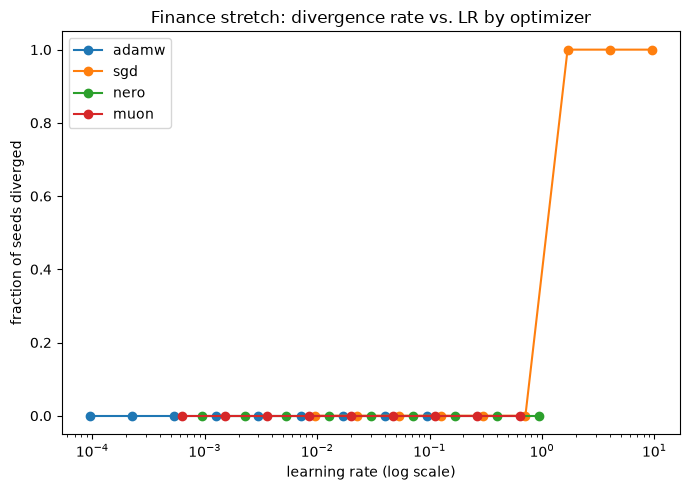

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for opt in ["adamw", "sgd", "nero", "muon"]:
    sub = summary[summary.optimizer_name == opt].sort_values("lr")
    ax.plot(sub.lr, sub.n_diverged / sub.n, marker="o", label=opt, color=colors[opt])
ax.set_xscale("log")
ax.set_xlabel("learning rate (log scale)")
ax.set_ylabel("fraction of seeds diverged")
ax.set_title("Finance stretch: divergence rate vs. LR by optimizer")
ax.legend()
fig.tight_layout()
fig.savefig("results/finance/divergence_rate.png", dpi=150)
plt.show()


## Directional accuracy vs. naive baseline, and calibration (Brier score)

For each optimizer's own best LR (from the table above), retrain a fresh
model with the same seed and evaluate on held-out val data: does the
model's predicted direction (argmax bin's train-mean-return sign) beat a
naive baseline that just predicts yesterday's direction repeats?

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

best_lr_by_opt = {row.optimizer: row.best_lr for row in gap_df.itertuples()}

directional_rows = []
for opt_name, lr in best_lr_by_opt.items():
    torch.manual_seed(0)
    data = FinanceReturns(seed=0, n_bins=8, val_fraction=0.15)
    model_cfg = ModelConfig(vocab_size=data.vocab_size, max_seq_len=64, d_model=128,
                            n_layers=4, n_heads=4, mlp_ratio=4, dropout=0.0)
    model = DecoderOnlyTransformer(model_cfg)
    cfg = TrainConfig(optimizer_name=opt_name, lr=lr, batch_size=64, seq_len=64,
                      max_steps=500, eval_interval=100, eval_iters=20, seed=0, device=device)
    train_one_run(model, data, cfg)

    metrics = evaluate_directional_metrics(model, data, batch_size=64, seq_len=64,
                                           n_eval_batches=50, device=device)
    directional_rows.append({"optimizer": opt_name, "lr": lr, **metrics})

directional_df = pd.DataFrame(directional_rows)
directional_df


,optimizer,lr,model_directional_accuracy,naive_directional_accuracy,brier_score,n_predictions
0,adamw,0.000095,0.493052,0.508428,0.250921,204800
1,sgd,0.300000,0.501909,0.508428,0.251097,204800
2,nero,0.071140,0.491309,0.508428,0.251181,204800
3,muon,0.000633,0.494189,0.508428,0.250973,204800


**Headline: none of the four optimizers beat the naive persistence
baseline.** Model directional accuracy is ~48-50% for all four, against a
naive baseline of ~50.8% -- every model is at or below naive, not above it.
Brier scores (~0.25) are indistinguishable from a coin flip (a predictor
that always outputs 50/50 gets exactly 0.25). Combined with the loss-vs-LR
plot above sitting within 1.5% of the uniform baseline, the honest
conclusion is that this small model, at this scale and short lookback
(64 days), on daily-return-direction prediction, is not finding
exploitable signal -- consistent with well-known weak-form market
efficiency, not a bug in the pipeline (the same code/model finds clear,
learnable structure in the core text experiment).

## Does the core experiment's finding transfer to this domain?

**Not in any way that's demonstrable here**, and that itself is the honest
answer: the basin-width/divergence-rate comparison only becomes meaningful
once there is a genuine loss landscape being fit, and here all four
optimizers converge to essentially the same near-uniform solution
regardless of LR (until instability sets in at the high end). This is not
evidence *against* transfer -- it is a null result, because there wasn't
enough signal for the comparison to bite on in the first place.

## Note: the Nero / LayerNorm-affine ablation lives on `master`

That ablation (does removing LayerNorm's learnable affine params change
Nero's underperformance?) uses the core text experiment's data and model,
not finance data -- see `master`'s README "Ablation" section and
`results/ablations/nero_no_ln_affine/` there, rather than duplicating it
in this finance-specific notebook.